

# **1.   Mount and Dataset Imports**



In [31]:
import os
import numpy as np
import pandas as pd

In [32]:
import os

# Base Kaggle dataset path
base_path = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset"

# Train & Test folders
train = os.path.join(base_path, 'train')
test = os.path.join(base_path, 'test')

# Categories
categories = ["benign", "malignant"]

print("Train path:", train)
print("Test path:", test)
print("Categories:", categories)

Train path: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train
Test path: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test
Categories: ['benign', 'malignant']


In [33]:
# Collect all image file paths and their labels from train and test directories
image_paths = []
labels = []

for data_type in [train, test]:
    for category in categories:
        category_path = os.path.join(data_type, category)
        if os.path.exists(category_path):
            for image_name in os.listdir(category_path):
                image_path = os.path.join(category_path, image_name)
                image_paths.append(image_path)
                labels.append(category)  # Label is the folder name: 'benign' or 'malignant'
        else:
            print(f"Directory not found: {category_path}")


In [34]:
# Create DataFrame with image paths and labels
df = pd.DataFrame({'image_path': image_paths, 'label': labels})

In [35]:
df.head()

,image_path,label
0,/kaggle/input/melanoma-skin-cancer-dataset-of-...,benign
1,/kaggle/input/melanoma-skin-cancer-dataset-of-...,benign
2,/kaggle/input/melanoma-skin-cancer-dataset-of-...,benign
3,/kaggle/input/melanoma-skin-cancer-dataset-of-...,benign
4,/kaggle/input/melanoma-skin-cancer-dataset-of-...,benign


In [36]:
df.tail()

,image_path,label
10600,/kaggle/input/melanoma-skin-cancer-dataset-of-...,malignant
10601,/kaggle/input/melanoma-skin-cancer-dataset-of-...,malignant
10602,/kaggle/input/melanoma-skin-cancer-dataset-of-...,malignant
10603,/kaggle/input/melanoma-skin-cancer-dataset-of-...,malignant
10604,/kaggle/input/melanoma-skin-cancer-dataset-of-...,malignant


In [37]:
df.shape

(10605, 2)

In [38]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [39]:
df['label'].unique()

array(['benign', 'malignant'], dtype=object)

In [40]:
df['label'].value_counts()

label
benign       5500
malignant    5105
Name: count, dtype: int64

# **2.   EDA**




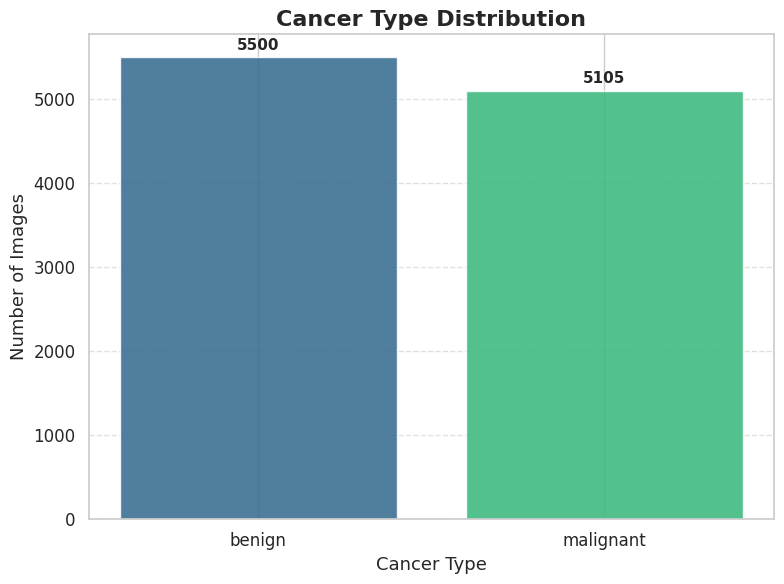

In [41]:
# Plot class distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Count images per class
label_counts = df['label'].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))
ax = plt.bar(label_counts.index, label_counts.values, color=colors, alpha=0.85)

# Add count labels above bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + max(label_counts.values)*0.01, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Axis labels and title
plt.title("Cancer Type Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Cancer Type", fontsize=13)
plt.ylabel("Number of Images", fontsize=13)

# Styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

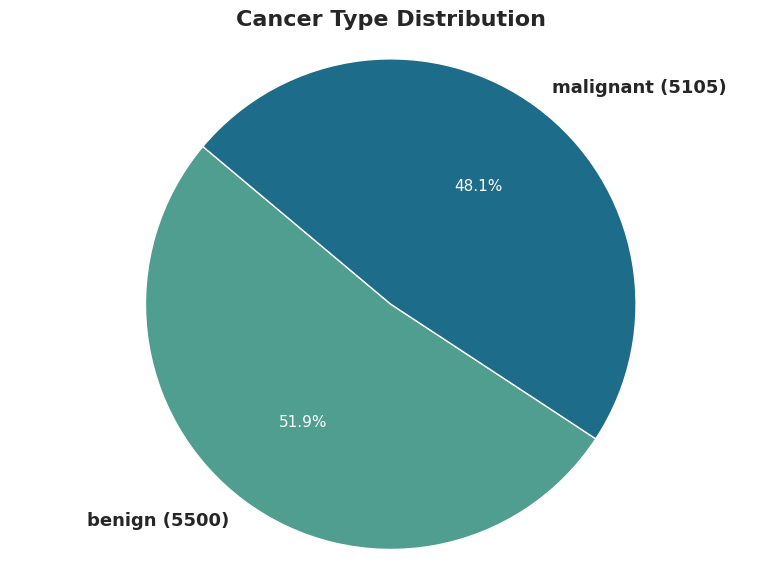

In [42]:
# Pie chart of class distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Count labels
label_counts = df['label'].value_counts()

# Format labels with class name and count
labels = [f'{label} ({count})' for label, count in zip(label_counts.index, label_counts.values)]

# Plot pie chart
plt.figure(figsize=(8, 6))
patches, texts, autotexts = plt.pie(
    label_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("crest", len(label_counts)),
    textprops={'fontsize': 12}
)

# Label styling
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

# Final formatting
plt.title("Cancer Type Distribution", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


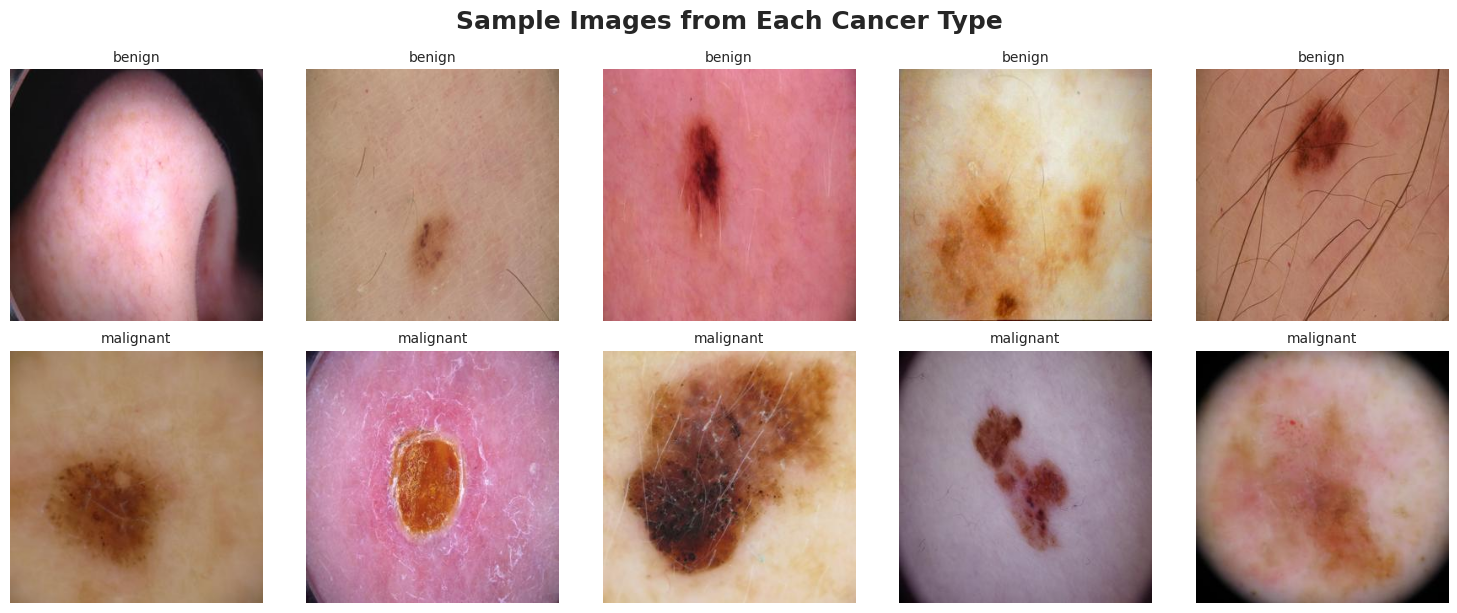

In [ ]:
# Display sample images per class
import matplotlib.pyplot as plt
import cv2

num_images = 5  # Images to show per category

plt.figure(figsize=(num_images * 3, len(categories) * 3))
plt.suptitle("Sample Images from Each Cancer Type", fontsize=18, fontweight='bold', y=1.02)

# Loop through each class and display sample images
for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt_idx = i * num_images + j + 1
        plt.subplot(len(categories), num_images, plt_idx)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


# **3.   Pre Proccessing**



## Label Encoding

In [ ]:
# Encode class labels as integers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['label'])

In [ ]:
# Keep only image paths and encoded labels
df = df[['image_path', 'category_encoded']]

In [46]:
# Show class-to-encoding mapping
category_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Category Encoding Mapping:")
for category, encoded_value in category_mapping.items():
    print(f"{category}: {encoded_value}")

Category Encoding Mapping:
benign: 0
malignant: 1


## Sampling


In [47]:
pip install -U scikit-learn==1.4.2 imbalanced-learn==0.12.2

Note: you may need to restart the kernel to use updated packages.


In [48]:
# Apply random oversampling to balance classes
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['category_encoded'])

# Create resampled DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['category_encoded'] = y_resampled

In [49]:
# Check class distribution after oversampling
print("\nClass distribution after oversampling:")
df_resampled['category_encoded'].value_counts()


Class distribution after oversampling:


category_encoded
0    5500
1    5500
Name: count, dtype: int64

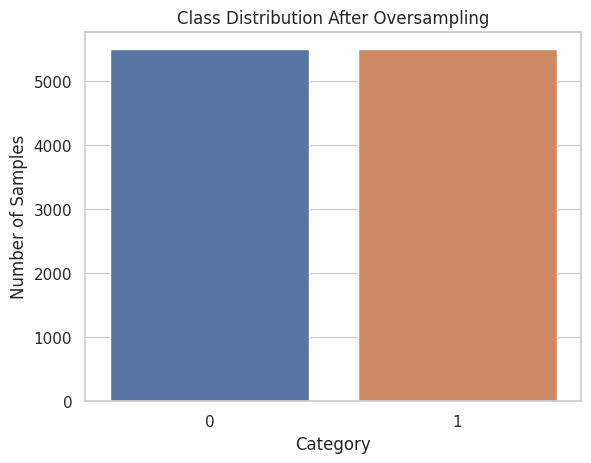

In [50]:
# Visualize class distribution after oversampling
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_resampled['category_encoded'])
plt.title("Class Distribution After Oversampling")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.show()


In [51]:
df_resampled

,image_path,category_encoded
0,/kaggle/input/melanoma-skin-cancer-dataset-of-...,0
1,/kaggle/input/melanoma-skin-cancer-dataset-of-...,0
2,/kaggle/input/melanoma-skin-cancer-dataset-of-...,0
3,/kaggle/input/melanoma-skin-cancer-dataset-of-...,0
4,/kaggle/input/melanoma-skin-cancer-dataset-of-...,0
...,...,...
10995,/kaggle/input/melanoma-skin-cancer-dataset-of-...,1
10996,/kaggle/input/melanoma-skin-cancer-dataset-of-...,1
10997,/kaggle/input/melanoma-skin-cancer-dataset-of-...,1
10998,/kaggle/input/melanoma-skin-cancer-dataset-of-...,1


## Train-Test Split

In [52]:
# Standard libraries
import time
import shutil
import pathlib
import itertools
import warnings

# Image handling
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Data handling and evaluation
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Activation, Dropout, BatchNormalization)
from tensorflow.keras import regularizers

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

print("✅ Setup complete.")


✅ Setup complete.


In [53]:
# Convert labels to string for compatibility with ImageDataGenerator
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [54]:
# Split into 80% train and 20% temp (for validation/test), with stratified sampling
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']
)
"""
# Sample 20% of training data for quicker testing
train_df_new = train_df_new.sample(frac=0.2, random_state=42).reset_index(drop=True)
"""
# Split remaining 20% into validation and test sets (10% each)
valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded']
)


In [55]:
print("Train set size:", len(train_df_new))
print("Validation set size:", len(valid_df_new))
print("Test set size:", len(test_df_new))

Train set size: 8800
Validation set size: 1100
Test set size: 1100


## Image Data Genarator

In [56]:
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
img_size = (224, 224)  # Or use (224, 224) for recommended performance
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Augmented training data generator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/test data generator (no augmentation)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Training generator
train_gen_new = train_datagen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

# Validation generator
valid_gen_new = test_datagen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

# Test generator
test_gen_new = test_datagen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)


Found 8800 validated image filenames belonging to 2 classes.
Found 1100 validated image filenames belonging to 2 classes.
Found 1100 validated image filenames belonging to 2 classes.



# **4.   Model Training**

## Callbacks

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [58]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',             # Monitor validation loss
    patience=5,                     # Stop if no improvement after 5 epochs
    restore_best_weights=True       # Restore model weights from best epoch
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',             # Monitor validation loss
    factor=0.5,                     # Reduce LR by a factor of 0.5
    patience=5,                     # Wait 3 epochs before reducing LR
    verbose=1,                      # Print LR updates
    min_lr=1e-6                     # Minimum learning rate
)


In [59]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, BatchNormalization,
                                     GaussianNoise, Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_densenet_model(input_shape, trainable=False):
    inputs = Input(shape=input_shape)

    # Load DenseNet121 base model (pretrained on ImageNet, exclude top FC layers)
    base_model = DenseNet121(weights='imagenet', input_tensor=inputs, include_top=False)

    # Freeze or unfreeze base model layers
    for layer in base_model.layers:
        layer.trainable = trainable

    x = base_model.output  # Shape depends on input size:
                           # → (None, 4, 4, 1024) for 128x128 input
                           # → (None, 7, 7, 1024) for 224x224 input

    # Attention block
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    x = Reshape((height * width, channels))(x)

    attention_output = MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)

    # Regularization and classification head
    x = GaussianNoise(0.25)(attention_output)
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = GaussianNoise(0.25)(x)
    x = Dropout(0.25)(x)

    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [ ]:
# Input shape for DenseNet
#input_shape = (128, 128, 3)              # ⚡ Fast testing shape
input_shape = (224, 224, 3)            # ✅ Recommended for DenseNet final training

# Build the model with DenseNet base (frozen weights)
cnn_model = create_densenet_model(input_shape, trainable=False)

# Show model architecture
cnn_model.summary()

# Compile the model
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),      # Adam optimizer with low learning rate
    loss='categorical_crossentropy',         # For multi-class (softmax) classification
    metrics=['accuracy']
)


I0000 00:00:1753797401.713099      97 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753797401.713881      97 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

 Non-trainable params: 7,038,528 (26.85 MB)

In [61]:
import time

# Phase 1: Train only the custom top layers
start_time = time.time()

history_phase1 = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

end_time = time.time()
print(f"\n Phase 1 training time: {(end_time - start_time)/60:.2f} minutes")


Epoch 1/15


I0000 00:00:1753797430.132481     165 service.cc:148] XLA service 0x3a2368d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753797430.133507     165 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753797430.133530     165 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753797433.025416     165 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/550 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.5938 - loss: 0.8408   

I0000 00:00:1753797446.314924     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


550/550 ━━━━━━━━━━━━━━━━━━━━ 190s 277ms/step - accuracy: 0.8287 - loss: 0.4266 - val_accuracy: 0.9182 - val_loss: 0.1936 - learning_rate: 1.0000e-04
Epoch 2/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 105s 190ms/step - accuracy: 0.8903 - loss: 0.2931 - val_accuracy: 0.9200 - val_loss: 0.1982 - learning_rate: 1.0000e-04
Epoch 3/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 105s 191ms/step - accuracy: 0.8968 - loss: 0.2724 - val_accuracy: 0.9236 - val_loss: 0.2052 - learning_rate: 1.0000e-04
Epoch 4/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 105s 191ms/step - accuracy: 0.9110 - loss: 0.2368 - val_accuracy: 0.9418 - val_loss: 0.1473 - learning_rate: 1.0000e-04
Epoch 5/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 107s 194ms/step - accuracy: 0.9085 - loss: 0.2302 - val_accuracy: 0.9336 - val_loss: 0.1751 - learning_rate: 1.0000e-04
Epoch 6/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 107s 194ms/step - accuracy: 0.9256 - loss: 0.1968 - val_accuracy: 0.9209 - val_loss: 0.1967 - learning_rate: 1.0000e-04
Epoch 7/15
550/550 ━━━━━━━━━━━━━━━━━━━━ 107s 195ms/

In [62]:
from tensorflow.keras.layers import Conv2D  # ✅ DenseNet uses only Conv2D

n = 10  # Number of convolutional layers to unfreeze

def unfreeze_last_conv_layers(model, n):
    """
    Unfreezes the last `n` Conv2D layers in the given model and prints their names.

    Parameters:
    - model: Keras model object (e.g., cnn_model)
    - n: Number of convolutional layers to unfreeze (starting from the end)
    """
    conv_count = 0
    print(f"\n🔓 Unfreezing last {n} Conv2D layers:")

    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):  # ✅ DenseNet uses Conv2D (not SeparableConv2D)
            layer.trainable = True
            print(f"  ➤ {layer.name}")
            conv_count += 1
            if conv_count >= n:
                break

    if conv_count == 0:
        print("⚠️ No Conv2D layers found in the model.")

# Apply layer unfreezing
unfreeze_last_conv_layers(cnn_model, n=n)

# Recompile model with a lower learning rate for fine-tuning
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



🔓 Unfreezing last 10 Conv2D layers:
  ➤ conv5_block16_2_conv
  ➤ conv5_block16_1_conv
  ➤ conv5_block15_2_conv
  ➤ conv5_block15_1_conv
  ➤ conv5_block14_2_conv
  ➤ conv5_block14_1_conv
  ➤ conv5_block13_2_conv
  ➤ conv5_block13_1_conv
  ➤ conv5_block12_2_conv
  ➤ conv5_block12_1_conv


In [63]:
import time

# Phase 2: Fine-tune
start_time = time.time()

history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

end_time = time.time()
print(f"\n Phase 2 training time: {(end_time - start_time)/60:.2f} minutes")


Epoch 1/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 168s 240ms/step - accuracy: 0.9201 - loss: 0.2155 - val_accuracy: 0.9445 - val_loss: 0.1465 - learning_rate: 1.0000e-05
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 110s 200ms/step - accuracy: 0.9278 - loss: 0.1925 - val_accuracy: 0.9436 - val_loss: 0.1462 - learning_rate: 1.0000e-05
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 107s 194ms/step - accuracy: 0.9249 - loss: 0.1902 - val_accuracy: 0.9491 - val_loss: 0.1423 - learning_rate: 1.0000e-05
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 106s 193ms/step - accuracy: 0.9223 - loss: 0.1948 - val_accuracy: 0.9391 - val_loss: 0.1744 - learning_rate: 1.0000e-05
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 105s 192ms/step - accuracy: 0.9247 - loss: 0.2031 - val_accuracy: 0.9464 - val_loss: 0.1414 - learning_rate: 1.0000e-05
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 107s 195ms/step - accuracy: 0.9234 - loss: 0.1894 - val_accuracy: 0.9445 - val_loss: 0.1445 - learning_rate: 1.0000e-05
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 

# **5.   Model Evaluation**






## Explainable AI (GRAD CAM)

📷 Grad-CAM for image: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/malignant/melanoma_5327.jpg
📌 Using Conv Layer for Grad-CAM: conv5_block16_2_conv
✅ Predicted Class: Malignant | Confidence: 98.65%
🎯 True Class: Malignant


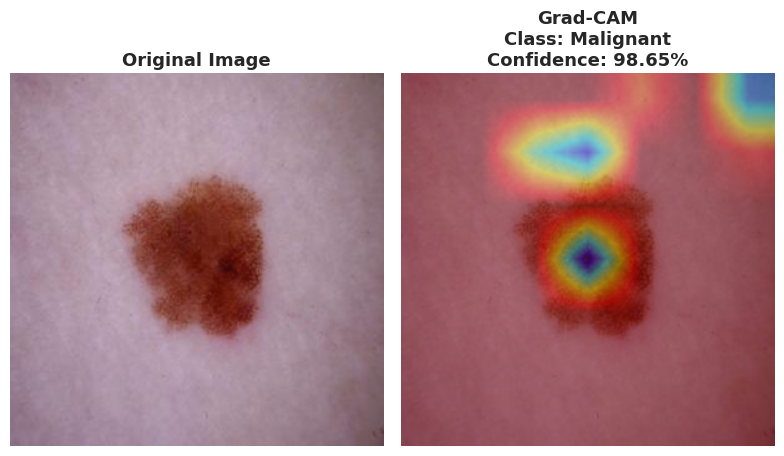

📷 Grad-CAM for image: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/malignant/melanoma_9255.jpg
📌 Using Conv Layer for Grad-CAM: conv5_block16_2_conv
✅ Predicted Class: Malignant | Confidence: 99.92%
🎯 True Class: Malignant


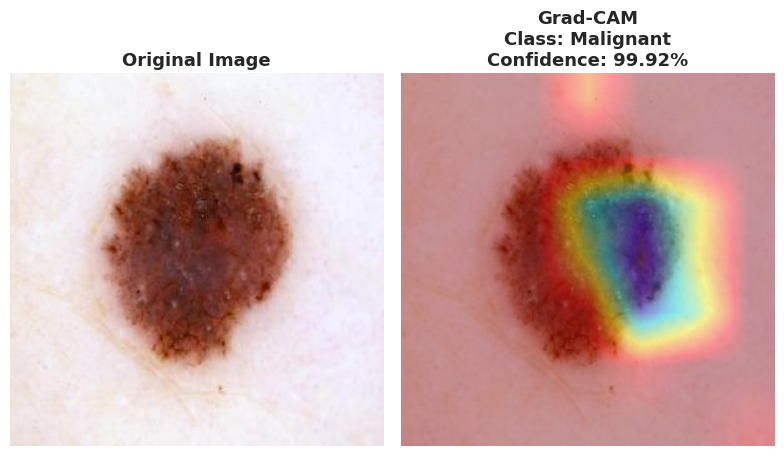

📷 Grad-CAM for image: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/benign/melanoma_508.jpg
📌 Using Conv Layer for Grad-CAM: conv5_block16_2_conv
✅ Predicted Class: Benign | Confidence: 99.73%
🎯 True Class: Benign


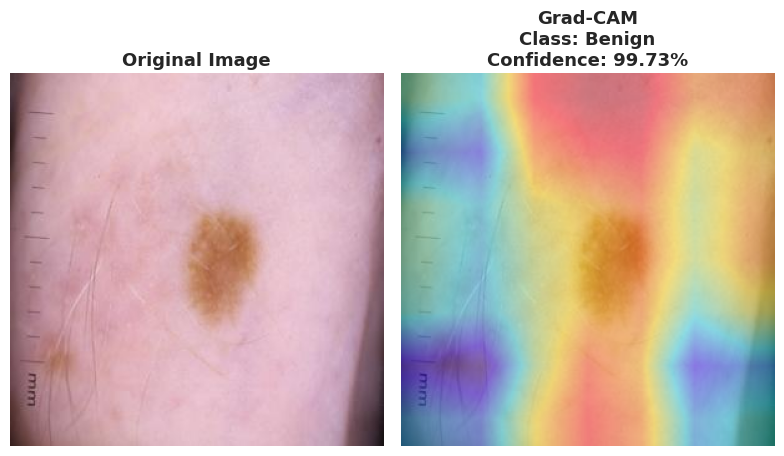

In [64]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.layers import Conv2D, SeparableConv2D
from tensorflow.keras.applications.densenet import preprocess_input  # Change to xception if needed

# Class names
class_names = ['Benign', 'Malignant']

# Load and preprocess image
def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

# Get last Conv2D or SeparableConv2D layer name (for Grad-CAM)
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, (Conv2D, SeparableConv2D)):
            return layer.name
    raise ValueError("⚠️ No Conv2D or SeparableConv2D layer found in the model.")

# Create Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

# Display Grad-CAM side-by-side
def display_gradcam_side_by_side(img_path, heatmap, alpha=0.4, pred_class=None, confidence=None):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(heatmap_color, alpha, img, 1 - alpha, 0)

    fig, axs = plt.subplots(1, 2, figsize=(8, 5))
    axs[0].imshow(img)
    axs[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axs[0].axis('off')

    title = f'Grad-CAM\nClass: {pred_class}\nConfidence: {confidence*100:.2f}%' if pred_class else 'Grad-CAM'
    axs[1].imshow(superimposed_img)
    axs[1].set_title(title, fontsize=13, fontweight='bold')
    axs[1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

# Wrapper to run Grad-CAM on a single image
def run_gradcam_on_image(img_path, model, class_names, test_df, alpha=0.4):
    input_size = tuple(model.input.shape[1:3])
    img_array = get_img_array(img_path, size=input_size)

    preds = model.predict(img_array, verbose=0)
    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index]
    pred_label = class_names[pred_index]

    # ✅ Convert 0 or 1 from DataFrame to class name
    true_label_index = int(test_df.loc[test_df['image_path'] == img_path, 'category_encoded'].values[0])
    true_label = class_names[true_label_index]

    last_conv_layer_name = get_last_conv_layer_name(model)
    print(f"📷 Grad-CAM for image: {img_path}")
    print(f"📌 Using Conv Layer for Grad-CAM: {last_conv_layer_name}")
    print(f"✅ Predicted Class: {pred_label} | Confidence: {confidence * 100:.2f}%")
    print(f"🎯 True Class: {true_label}")

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index)
    display_gradcam_side_by_side(img_path, heatmap, alpha=alpha, pred_class=pred_label, confidence=confidence)

# 🔍 Run Grad-CAM on 3 random test images
sample_images = test_df_new.sample(3)['image_path'].values

for img_path in sample_images:
    run_gradcam_on_image(img_path, cnn_model, class_names, test_df=test_df_new)


## Accuracy - Loss per Epoch

In [65]:
# Plot training and validation accuracy/loss curves
def plot_training_curves(history, title='Training History'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Train Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Val Acc')
    plt.title('Accuracy', fontsize=13)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Train Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Val Loss')
    plt.title('Loss', fontsize=13)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()


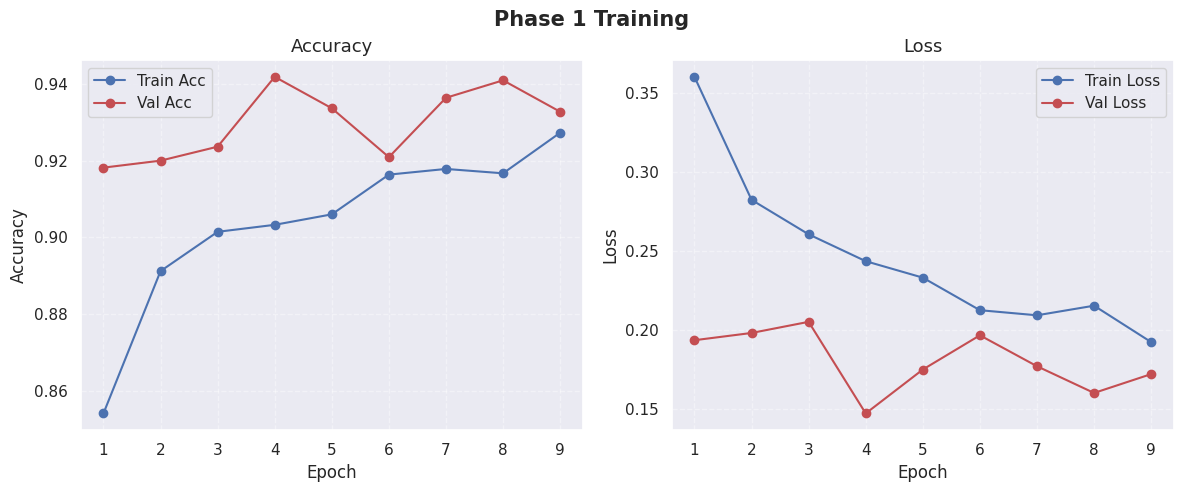

In [66]:
plot_training_curves(history_phase1, title='Phase 1 Training')

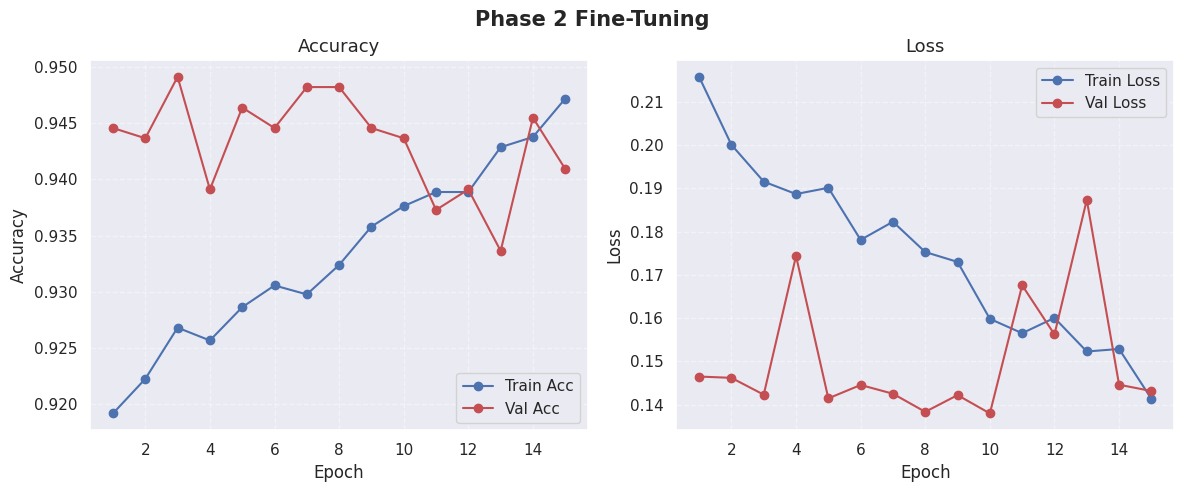

In [67]:
plot_training_curves(history, title='Phase 2 Fine-Tuning')

## Classification Report

In [68]:
# Get ground-truth and predicted class labels
test_labels = test_gen_new.classes                                 # True labels
predictions = cnn_model.predict(test_gen_new, verbose=0)          # Model predictions (softmax probs)
predicted_classes = np.argmax(predictions, axis=1)                # Convert to class indices


In [69]:
# Print text classification report with class names from test generator
report = classification_report(test_labels, predicted_classes, target_names=list(test_gen_new.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       550
           1       0.93      0.92      0.92       550

    accuracy                           0.92      1100
   macro avg       0.92      0.92      0.92      1100
weighted avg       0.92      0.92      0.92      1100



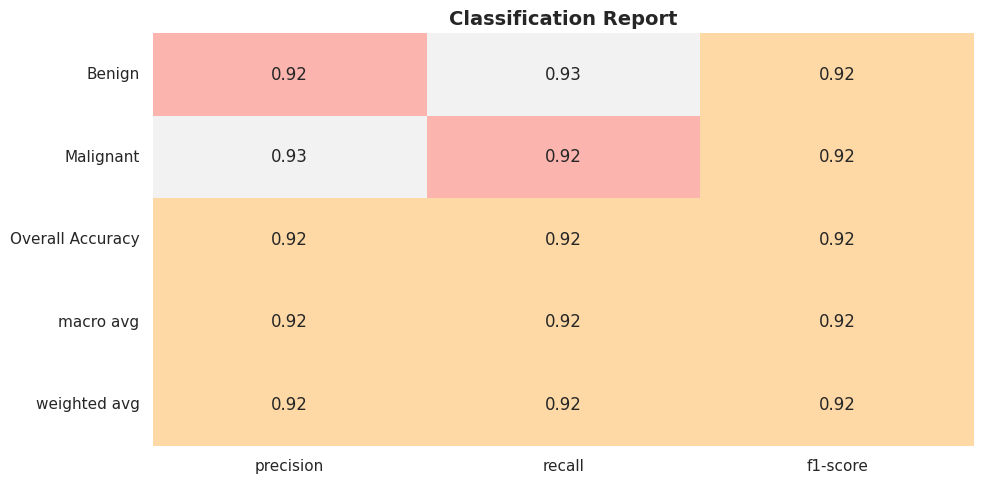

In [70]:
# Define readable class labels
class_names = ['Benign', 'Malignant']

# Generate classification report as a dictionary
report_dict = classification_report(
    test_labels,
    predicted_classes,
    labels=[0, 1],
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame and round values
report_df = pd.DataFrame(report_dict).transpose().round(3)

# Rename 'accuracy' row for readability
report_df.rename(index={'accuracy': 'Overall Accuracy'}, inplace=True)

# Plot classification metrics (excluding 'support' column)
plt.figure(figsize=(10, 5))
sns.heatmap(
    report_df.drop(columns='support', errors='ignore'),
    annot=True, fmt=".2f", cmap="Pastel1", cbar=False
)

plt.title("Classification Report", fontsize=14, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Confusion Matrix


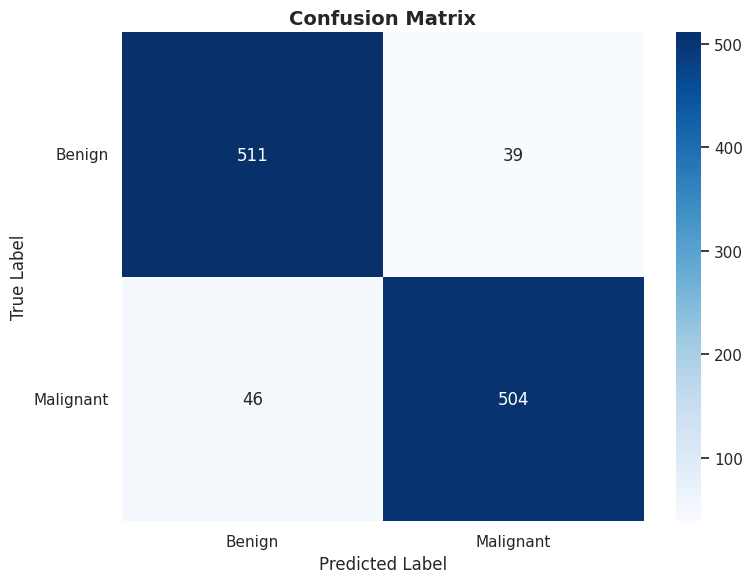

In [71]:
# Define consistent class names
class_names = ['Benign', 'Malignant']

# Compute confusion matrix
conf_matrix = confusion_matrix(test_labels, predicted_classes, labels=[0, 1])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## ROC Curve

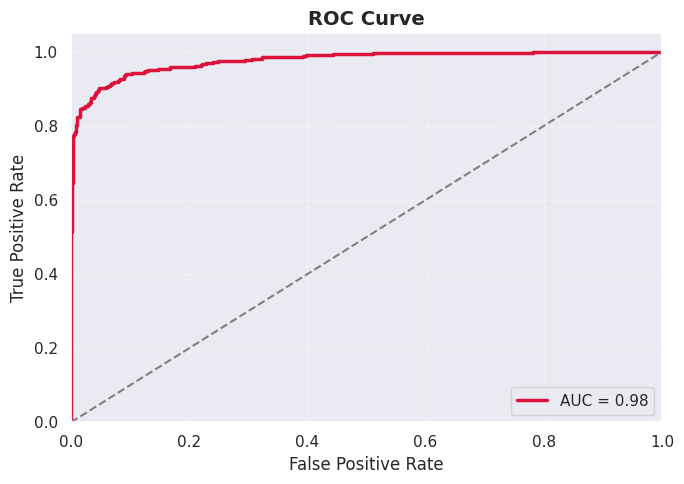

In [72]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class (Malignant)
y_pred_prob = predictions[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', lw=2.5, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
